# RUL Prediction: Hybrid Transformer Models
## LSTM-Transformer, GRU-Transformer, CNN-Transformer Architectures
**Owen's Implementation - Team Deep Learning Project**

# Hyperparameter Tuning (FD001)
- Models: LSTM-Transformer, GRU-Transformer, CNN-Transformer.
- Datasets: FE - Manual (Drop s14), FE - Manual (Drop s14, s11).
- Tune: sequence length and learning rate.
- Metric: RMSE for train, val, test (select best by val RMSE).
- Save best model per seed into: owen/models/hyper.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

SEEDS = [1234, 42, 999]
BATCH_SIZE = 64
TRAIN_TEST_SPLIT = 0.8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

Using device: cuda


In [4]:
# %cd Tearm_8/50.039_DL/DL_Project/
cwd = os.getcwd()
print("Current working directory:", cwd)
# %cd sutd_50039_deep_learning

Current working directory: /home/sagemaker-user
/home/sagemaker-user/sutd_50039_deep_learning


In [5]:
# Two best datasets for tuning
train_df_low_variance_1_125 = pd.read_csv(
    'data/processed-nasa-data/feature_engineering_2/low_variance_1/train_fd001_low_variance_1_125.csv'
 )
test_df_low_variance_1_125 = pd.read_csv(
    'data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd001_low_variance_1_125.csv'
 )

DATASETS_CONFIG = {
    'FE Low Variance 125': (train_df_low_variance_1_125, test_df_low_variance_1_125),
}

In [6]:
class RULDataset(Dataset):
    def __init__(self, df, sequence_length=30, feature_cols=None):
        self.sequence_length = sequence_length
        if feature_cols is None:
            self.feature_cols = [col for col in df.columns if col[0] == 's' and col[1:].isdigit()]
        else:
            self.feature_cols = feature_cols

        self.sequences = []
        self.labels = []
        for engine_id in df['id'].unique():
            engine_data = df[df['id'] == engine_id].sort_values('cycle').reset_index(drop=True)
            features = engine_data[self.feature_cols].values
            rul = engine_data['RUL'].values
            for i in range(len(engine_data) - sequence_length):
                self.sequences.append(features[i:i + sequence_length])
                self.labels.append(rul[i + sequence_length])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.labels[idx])

def build_loaders_by_seed(sequence_length):
    base_datasets = {}
    test_datasets = {}
    for dataset_name, (train_df, test_df) in DATASETS_CONFIG.items():
        train_dataset = RULDataset(train_df, sequence_length)
        test_dataset = RULDataset(test_df, sequence_length, feature_cols=train_dataset.feature_cols)
        base_datasets[dataset_name] = train_dataset
        test_datasets[dataset_name] = test_dataset

    loaders_by_seed = {}
    for seed in SEEDS:
        seed_everything(seed)
        loaders_by_seed[seed] = {}
        for dataset_name in base_datasets.keys():
            train_dataset = base_datasets[dataset_name]
            test_dataset = test_datasets[dataset_name]
            train_size = int(TRAIN_TEST_SPLIT * len(train_dataset))
            val_size = len(train_dataset) - train_size
            train_split, val_split = random_split(
                train_dataset,
                [train_size, val_size],
                generator=torch.Generator().manual_seed(seed)
            )
            train_loader = DataLoader(
                train_split,
                batch_size=BATCH_SIZE,
                shuffle=True,
                num_workers=0,
                worker_init_fn=seed_worker
            )
            val_loader = DataLoader(
                val_split,
                batch_size=BATCH_SIZE,
                shuffle=False,
                num_workers=0,
                worker_init_fn=seed_worker
            )
            test_loader = DataLoader(
                test_dataset,
                batch_size=BATCH_SIZE,
                shuffle=False,
                num_workers=0,
                worker_init_fn=seed_worker
            )
            loaders_by_seed[seed][dataset_name] = {
                'train': train_loader,
                'val': val_loader,
                'test': test_loader,
                'num_features': len(train_dataset.feature_cols)
            }
    return loaders_by_seed

In [9]:
class LSTMTransformer(nn.Module):
    def __init__(self, num_features, lstm_hidden=64, num_lstm_layers=2, d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=lstm_hidden,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0
        )
        self.projection = nn.Linear(lstm_hidden, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        transformer_in = self.projection(lstm_out)
        transformer_out = self.transformer(transformer_in)
        last_output = transformer_out[:, -1, :]
        return self.fc(last_output).squeeze(-1)

class GRUTransformer(nn.Module):
    def __init__(self, num_features, gru_hidden=64, num_gru_layers=2, d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=num_features,
            hidden_size=gru_hidden,
            num_layers=num_gru_layers,
            batch_first=True,
            dropout=dropout if num_gru_layers > 1 else 0
        )
        self.projection = nn.Linear(gru_hidden, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        gru_out, _ = self.gru(x)
        transformer_in = self.projection(gru_out)
        transformer_out = self.transformer(transformer_in)
        last_output = transformer_out[:, -1, :]
        return self.fc(last_output).squeeze(-1)

class CNNTransformer(nn.Module):
    def __init__(self, num_features, num_filters=32, kernel_size=3, d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super().__init__()
        self.conv1d = nn.Sequential(
            nn.Conv1d(
                in_channels=num_features,
                out_channels=num_filters,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            ),
            nn.ReLU(),
            nn.BatchNorm1d(num_filters),
            nn.Dropout(dropout)
        )
        self.projection = nn.Linear(num_filters, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        x = x.transpose(1, 2)
        cnn_out = self.conv1d(x)
        cnn_out = cnn_out.transpose(1, 2)
        transformer_in = self.projection(cnn_out)
        transformer_out = self.transformer(transformer_in)
        last_output = transformer_out[:, -1, :]
        return self.fc(last_output).squeeze(-1)

In [10]:
def evaluate_rmse(model, data_loader, device):
    model.eval()
    total_sse = 0.0
    total_count = 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            total_sse += torch.sum((preds - y_batch) ** 2).item()
            total_count += y_batch.numel()
    return np.sqrt(total_sse / max(total_count, 1))

def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    device,
    lr,
    epochs,
    meta=None,
    remaining_trials=None,
    return_history=False
):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    best_val_rmse = float('inf')
    best_model_state = None
    history = {"train": [], "val": [], "test": []}
    
    for epoch in range(1, epochs + 1):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # Evaluate current performance
        curr_train_rmse = evaluate_rmse(model, train_loader, device)
        curr_val_rmse = evaluate_rmse(model, val_loader, device)
        
        # SAVE BEST MODEL BASED ON VALIDATION ONLY
        if curr_val_rmse < best_val_rmse:
            best_val_rmse = curr_val_rmse
            best_model_state = model.state_dict().copy()
        
        # Printing metadata for current epoch (Excluding Test RMSE for now)
        if meta is not None:
            d_model_str = f" | d_model={meta.get('d_model', 'N/A')}"
            remaining = f" | remaining: {remaining_trials}" if remaining_trials is not None else ""
            
            print(f"Epoch {epoch}/{epochs} | Seed: {meta['seed']} | {meta['dataset']} | {meta['model']} "
                  f"| Seq: {meta['seq_len']} | LR: {meta['lr']}{d_model_str} "
                  f"| Train: {curr_train_rmse:.4f} | Val: {curr_val_rmse:.4f}{remaining}")

        if return_history:
            history["train"].append(curr_train_rmse)
            history["val"].append(curr_val_rmse)

    # --- FINAL TEST EVALUATION (After all epochs) ---
    # Load the best weights found during validation
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    final_test_rmse = evaluate_rmse(model, test_loader, device)
    final_train_rmse = evaluate_rmse(model, train_loader, device)
    final_val_rmse = evaluate_rmse(model, val_loader, device)
    
    print(f"\n Final Results for this Trial:")
    print(f">> Best Val RMSE: {final_val_rmse:.4f} | Final Test RMSE: {final_test_rmse:.4f}\n" + "="*50)

    if return_history:
        return model, final_train_rmse, final_val_rmse, final_test_rmse, history
    return model, final_train_rmse, final_val_rmse, final_test_rmse

In [10]:
SEQ_LENS = [30, 50, 100]
LRS = [1e-4, 5e-5, 1e-3]
D_MODELS = [32, 64, 128]
EPOCHS = 5

MODEL_FACTORIES = {
    'LSTM-Transformer': lambda nf, d: LSTMTransformer(num_features=nf, lstm_hidden=64, num_lstm_layers=2, d_model=d, nhead=4, num_transformer_layers=2, dropout=0.1),
    'GRU-Transformer': lambda nf, d: GRUTransformer(num_features=nf, gru_hidden=64, num_gru_layers=2, d_model=d, nhead=4, num_transformer_layers=2, dropout=0.1),
    'CNN-Transformer': lambda nf, d: CNNTransformer(num_features=nf, num_filters=32, kernel_size=3, d_model=d, nhead=4, num_transformer_layers=2, dropout=0.1),
}

save_dir = Path('sutd_50039_deep_learning/owen/models/hyper')
save_dir.mkdir(parents=True, exist_ok=True)
log_dir = Path('sutd_50039_deep_learning/owen/logs')
log_dir.mkdir(parents=True, exist_ok=True)

results = []
total_trials = len(SEQ_LENS) * len(SEEDS) * len(DATASETS_CONFIG) * len(MODEL_FACTORIES) * len(LRS) * len(D_MODELS)
trial_idx = 0

for seq_len in SEQ_LENS:
    loaders_by_seed = build_loaders_by_seed(seq_len)
    for seed in SEEDS:
        seed_everything(seed)
        for dataset_name in DATASETS_CONFIG.keys():
            for model_name, make_model in MODEL_FACTORIES.items():
                best_val = float('inf')
                best_row = None
                best_state = None
                for d_model in D_MODELS:
                    for lr in LRS:
                        trial_idx += 1
                        loaders = loaders_by_seed[seed][dataset_name]
                        model = make_model(loaders['num_features'], d_model)
                        meta = {
                            'seed': seed,
                            'dataset': dataset_name,
                            'model': model_name,
                            'seq_len': seq_len,
                            'lr': lr,
                            'd_model': d_model,
                        }
                        remaining = total_trials - trial_idx
                        model, train_rmse, val_rmse, test_rmse = train_model(
                            model,
                            loaders['train'],
                            loaders['val'],
                            loaders['test'],
                            DEVICE,
                            lr=lr,
                            epochs=EPOCHS,
                            meta=meta,
                            remaining_trials=remaining
                        )
                        test_rmse = evaluate_rmse(model, loaders['test'], DEVICE)
                        row = {
                            'Seed': seed,
                            'Dataset': dataset_name,
                            'Model': model_name,
                            'Seq Len': seq_len,
                            'LR': lr,
                            'D Model': d_model,
                            'Train RMSE': train_rmse,
                            'Val RMSE': val_rmse,
                            'Test RMSE': test_rmse
                        }
                        results.append(row)
                        if val_rmse < best_val:
                            best_val = val_rmse
                            best_row = row
                            best_state = model.state_dict()
                if best_state is not None:
                    safe_dataset = dataset_name.replace(' ', '_').replace('(', '').replace(')', '')
                    safe_model = model_name.replace('-', '_')
                    model_path = save_dir / f"{safe_model}_{safe_dataset}_seed{seed}_seq{best_row['Seq Len']}_d{best_row['D Model']}_lr{best_row['LR']}.pth"
                    torch.save(best_state, model_path)
                    print(f"Saved best: {model_path}")

results_df = pd.DataFrame(results)
results_df.sort_values(['Dataset', 'Model', 'Seed', 'Val RMSE'], inplace=True)

best_idx = results_df['Test RMSE'].idxmin()
best_row = results_df.loc[best_idx]
print(
    "Best overall | ",
    f"Dataset={best_row['Dataset']} | Model={best_row['Model']} | Seed={best_row['Seed']} | ",
    f"Seq={best_row['Seq Len']} | D Model={best_row['D Model']} | LR={best_row['LR']} | ",
    f"Train RMSE={best_row['Train RMSE']:.4f} | Val RMSE={best_row['Val RMSE']:.4f} | Test RMSE={best_row['Test RMSE']:.4f}"
 )

results_csv = log_dir / "hyper_results.csv"
results_df.to_csv(results_csv, index=False)
print(f"Saved results: {results_csv}")

results_df

Epoch 1/5 | Seed: 1234 | FE Low Variance 125 | LSTM-Transformer | Seq: 30 | LR: 0.0001 | d_model=32 | Train: 85.9182 | Val: 85.3697 | remaining: 242
Epoch 2/5 | Seed: 1234 | FE Low Variance 125 | LSTM-Transformer | Seq: 30 | LR: 0.0001 | d_model=32 | Train: 78.0417 | Val: 77.5084 | remaining: 242
Epoch 3/5 | Seed: 1234 | FE Low Variance 125 | LSTM-Transformer | Seq: 30 | LR: 0.0001 | d_model=32 | Train: 66.5873 | Val: 66.0896 | remaining: 242
Epoch 4/5 | Seed: 1234 | FE Low Variance 125 | LSTM-Transformer | Seq: 30 | LR: 0.0001 | d_model=32 | Train: 54.5337 | Val: 54.1118 | remaining: 242
Epoch 5/5 | Seed: 1234 | FE Low Variance 125 | LSTM-Transformer | Seq: 30 | LR: 0.0001 | d_model=32 | Train: 41.0808 | Val: 40.7327 | remaining: 242

 Final Results for this Trial:
>> Best Val RMSE: 40.7327 | Final Test RMSE: 50.8955
Epoch 1/5 | Seed: 1234 | FE Low Variance 125 | LSTM-Transformer | Seq: 30 | LR: 5e-05 | d_model=32 | Train: 88.3606 | Val: 87.8082 | remaining: 241
Epoch 2/5 | Seed: 1234

,Seed,Dataset,Model,Seq Len,LR,D Model,Train RMSE,Val RMSE,Test RMSE
215,42,FE Low Variance 125,CNN-Transformer,100,0.00100,128,6.787937,7.177503,14.401630
212,42,FE Low Variance 125,CNN-Transformer,100,0.00100,64,7.470298,7.645630,13.211753
209,42,FE Low Variance 125,CNN-Transformer,100,0.00100,32,8.079125,8.311154,13.331887
134,42,FE Low Variance 125,CNN-Transformer,50,0.00100,128,9.354626,9.498583,15.449747
131,42,FE Low Variance 125,CNN-Transformer,50,0.00100,64,9.709361,9.727063,14.260080
...,...,...,...,...,...,...,...,...,...
4,1234,FE Low Variance 125,LSTM-Transformer,30,0.00005,64,59.341568,58.881758,72.230909
85,1234,FE Low Variance 125,LSTM-Transformer,50,0.00005,64,60.333693,59.502472,75.250029
163,1234,FE Low Variance 125,LSTM-Transformer,100,0.00005,32,63.334841,60.696403,83.436558
82,1234,FE Low Variance 125,LSTM-Transformer,50,0.00005,32,71.635506,70.626141,88.673502


In [42]:
import matplotlib.pyplot as plt

# Best configuration found from hyperparameter tuning
BEST_SEED = 1234
BEST_DATASET = "FE Low Variance 125"
BEST_MODEL = "GRU-Transformer"
BEST_SEQ_LEN = 100
BEST_LR = 0.001
BEST_D_MODEL = 64

EPOCHS = 50

# Build loaders for the best configuration
loaders_by_seed = build_loaders_by_seed(BEST_SEQ_LEN)
loaders = loaders_by_seed[BEST_SEED][BEST_DATASET]

In [43]:
# Train best model with seed 1234
seed_everything(BEST_SEED)

model = GRUTransformer(
    num_features=loaders["num_features"],
    gru_hidden=64,
    num_gru_layers=2,
    d_model=BEST_D_MODEL,
    nhead=4,
    num_transformer_layers=2,
    dropout=0.1
)

model = model.to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)
loss_fn = nn.MSELoss()

best_val_rmse = float('inf')
best_model_state = None
history = {"train": [], "val": []}

print(f"Training with Seed={BEST_SEED} | {BEST_DATASET} | {BEST_MODEL}")
print(f"Config: Seq={BEST_SEQ_LEN} | LR={BEST_LR} | D_Model={BEST_D_MODEL}")
print("=" * 80)

# Training loop - evaluate train/val RMSE only
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for X_batch, y_batch in loaders["train"]:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    # Evaluate train and validation RMSE
    train_rmse = evaluate_rmse(model, loaders["train"], DEVICE)
    val_rmse = evaluate_rmse(model, loaders["val"], DEVICE)
    
    history["train"].append(train_rmse)
    history["val"].append(val_rmse)
    
    # Save best model based on validation RMSE
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_model_state = model.state_dict().copy()
    
    # Print every epoch
    print(f"Epoch {epoch:2d}/{EPOCHS} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

print("=" * 80)

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)

# Evaluate test RMSE ONLY AT THE END
test_rmse = evaluate_rmse(model, loaders["test"], DEVICE)
final_train_rmse = evaluate_rmse(model, loaders["train"], DEVICE)
final_val_rmse = evaluate_rmse(model, loaders["val"], DEVICE)

print(f"\nFinal Results:")
print(f"  Train RMSE: {final_train_rmse:.4f}")
print(f"  Val RMSE:   {final_val_rmse:.4f}")
print(f"  Test RMSE:  {test_rmse:.4f}")
print("=" * 80)

# Save model
save_dir = Path('Hybrid/models/best_hyper_model')
save_dir.mkdir(parents=True, exist_ok=True)
model_name = f"GRU_Transformer_{BEST_DATASET.replace(' ', '_')}_seed{BEST_SEED}_seq{BEST_SEQ_LEN}_d{BEST_D_MODEL}_lr{BEST_LR}.pth"
model_path = save_dir / model_name
torch.save(best_model_state, model_path)
print(f"Model saved: {model_path}")


Training with Seed=1234 | FE Low Variance 125 | GRU-Transformer
Config: Seq=100 | LR=0.001 | D_Model=64
Epoch  1/50 | Train RMSE: 13.0621 | Val RMSE: 12.3710
Epoch  2/50 | Train RMSE: 10.1602 | Val RMSE: 9.5908
Epoch  3/50 | Train RMSE: 10.0032 | Val RMSE: 9.4934
Epoch  4/50 | Train RMSE: 9.6638 | Val RMSE: 9.4114
Epoch  5/50 | Train RMSE: 9.8431 | Val RMSE: 9.6934
Epoch  6/50 | Train RMSE: 11.4100 | Val RMSE: 11.3494
Epoch  7/50 | Train RMSE: 9.2478 | Val RMSE: 9.0360
Epoch  8/50 | Train RMSE: 9.4982 | Val RMSE: 9.0975
Epoch  9/50 | Train RMSE: 9.5595 | Val RMSE: 9.1585
Epoch 10/50 | Train RMSE: 7.7808 | Val RMSE: 7.6933
Epoch 11/50 | Train RMSE: 7.9963 | Val RMSE: 7.7378
Epoch 12/50 | Train RMSE: 7.3144 | Val RMSE: 7.2977
Epoch 13/50 | Train RMSE: 6.8231 | Val RMSE: 6.8392
Epoch 14/50 | Train RMSE: 7.1906 | Val RMSE: 7.0373
Epoch 15/50 | Train RMSE: 6.8524 | Val RMSE: 6.9724
Epoch 16/50 | Train RMSE: 8.9275 | Val RMSE: 8.6905
Epoch 17/50 | Train RMSE: 6.5330 | Val RMSE: 6.7044
Epoch 

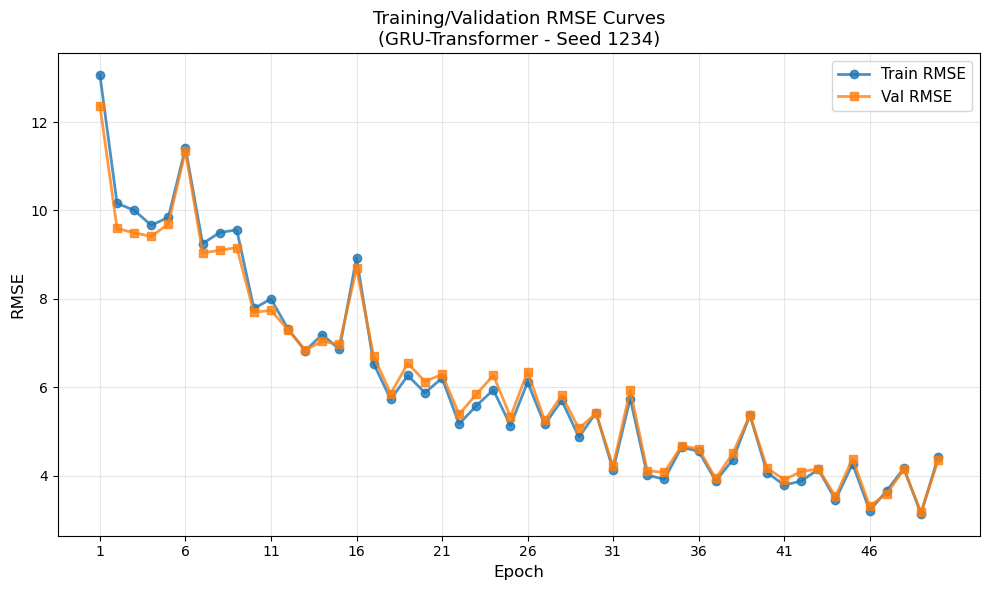

In [44]:
epochs_range = range(1, EPOCHS + 1)
sample_interval = 5

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history["train"], marker='o', linewidth=2, label='Train RMSE', alpha=0.8)
plt.plot(epochs_range, history["val"], marker='s', linewidth=2, label='Val RMSE', alpha=0.8)

# Mark every 5th epoch on x-axis
plt.xticks(range(1, EPOCHS + 1, sample_interval))
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title(f"Training/Validation RMSE Curves\n({BEST_MODEL} - Seed {BEST_SEED})", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
# Best hyperparameters for LSTM-Transformer

BEST_SEED = 999
BEST_DATASET = "FE Low Variance 125"
BEST_MODEL = "LSTM-Transformer"
BEST_SEQ_LEN = 100
BEST_LR = 0.001
BEST_D_MODEL = 32

EPOCHS = 50

seed_everything(BEST_SEED)

# Build loaders for the best configuration
loaders_by_seed = build_loaders_by_seed(BEST_SEQ_LEN)
loaders = loaders_by_seed[BEST_SEED][BEST_DATASET]

model = LSTMTransformer(
    num_features=loaders["num_features"], 
    lstm_hidden=64, 
    num_lstm_layers=2, 
    d_model=BEST_D_MODEL, 
    nhead=4, 
    num_transformer_layers=2, 
    dropout=0.1
)

model = model.to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)
loss_fn = nn.MSELoss()

best_val_rmse = float('inf')
best_model_state = None
history = {"train": [], "val": []}

print(f"Training with Seed={BEST_SEED} | {BEST_DATASET} | {BEST_MODEL}")
print(f"Config: Seq={BEST_SEQ_LEN} | LR={BEST_LR} | D_Model={BEST_D_MODEL}")
print("=" * 80)

# Training loop - evaluate train/val RMSE only
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for X_batch, y_batch in loaders["train"]:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    # Evaluate train and validation RMSE
    train_rmse = evaluate_rmse(model, loaders["train"], DEVICE)
    val_rmse = evaluate_rmse(model, loaders["val"], DEVICE)
    
    history["train"].append(train_rmse)
    history["val"].append(val_rmse)
    
    # Save best model based on validation RMSE
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_model_state = model.state_dict().copy()
    
    # Print every epoch
    print(f"Epoch {epoch:2d}/{EPOCHS} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

print("=" * 80)

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)

# Evaluate test RMSE ONLY AT THE END
test_rmse = evaluate_rmse(model, loaders["test"], DEVICE)
final_train_rmse = evaluate_rmse(model, loaders["train"], DEVICE)
final_val_rmse = evaluate_rmse(model, loaders["val"], DEVICE)

print(f"\nFinal Results:")
print(f"  Train RMSE: {final_train_rmse:.4f}")
print(f"  Val RMSE:   {final_val_rmse:.4f}")
print(f"  Test RMSE:  {test_rmse:.4f}")
print("=" * 80)

# Save model
save_dir = Path('Hybrid/models/best_hyper_model')
save_dir.mkdir(parents=True, exist_ok=True)
model_name = f"LSTM_Transformer_{BEST_DATASET.replace(' ', '_')}_seed{BEST_SEED}_seq{BEST_SEQ_LEN}_d{BEST_D_MODEL}_lr{BEST_LR}.pth"
model_path = save_dir / model_name
torch.save(best_model_state, model_path)
print(f"Model saved: {model_path}")


Training with Seed=999 | FE Low Variance 125 | LSTM-Transformer
Config: Seq=100 | LR=0.001 | D_Model=32
Epoch  1/50 | Train RMSE: 25.8063 | Val RMSE: 25.4712
Epoch  2/50 | Train RMSE: 11.1082 | Val RMSE: 10.6349
Epoch  3/50 | Train RMSE: 10.3637 | Val RMSE: 9.9057
Epoch  4/50 | Train RMSE: 11.2439 | Val RMSE: 10.8252
Epoch  5/50 | Train RMSE: 10.4982 | Val RMSE: 9.9086
Epoch  6/50 | Train RMSE: 9.6346 | Val RMSE: 9.2071
Epoch  7/50 | Train RMSE: 10.0940 | Val RMSE: 9.7972
Epoch  8/50 | Train RMSE: 10.7151 | Val RMSE: 10.2145
Epoch  9/50 | Train RMSE: 10.4950 | Val RMSE: 10.3579
Epoch 10/50 | Train RMSE: 10.6710 | Val RMSE: 10.5747
Epoch 11/50 | Train RMSE: 8.1980 | Val RMSE: 7.9060
Epoch 12/50 | Train RMSE: 7.4775 | Val RMSE: 7.5073
Epoch 13/50 | Train RMSE: 7.5280 | Val RMSE: 7.4650
Epoch 14/50 | Train RMSE: 7.8699 | Val RMSE: 7.8885
Epoch 15/50 | Train RMSE: 7.7037 | Val RMSE: 7.6658
Epoch 16/50 | Train RMSE: 7.6604 | Val RMSE: 7.6978
Epoch 17/50 | Train RMSE: 7.0801 | Val RMSE: 7.08

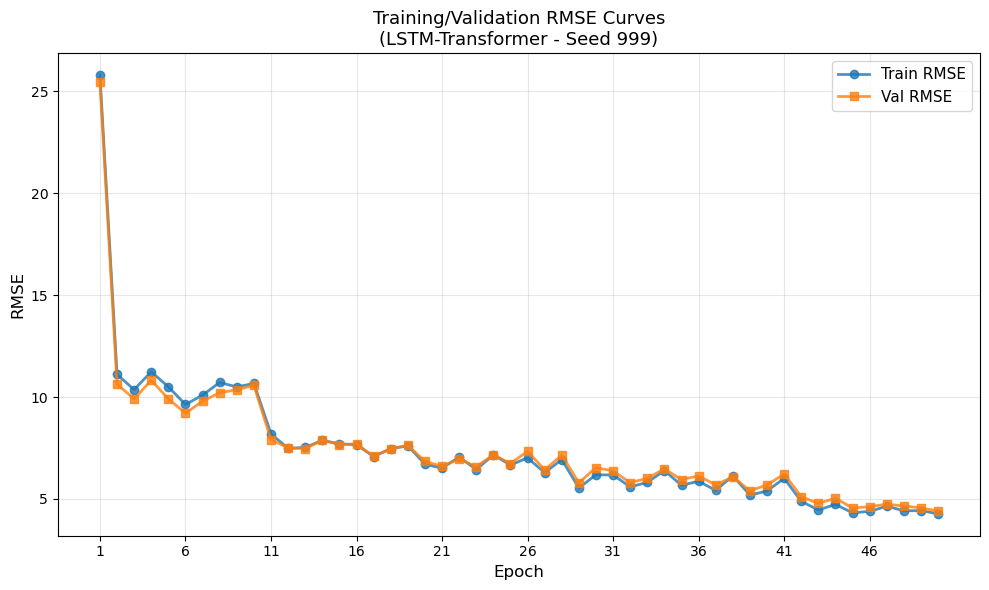

In [46]:
epochs_range = range(1, EPOCHS + 1)
sample_interval = 5

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history["train"], marker='o', linewidth=2, label='Train RMSE', alpha=0.8)
plt.plot(epochs_range, history["val"], marker='s', linewidth=2, label='Val RMSE', alpha=0.8)

# Mark every 5th epoch on x-axis
plt.xticks(range(1, EPOCHS + 1, sample_interval))
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title(f"Training/Validation RMSE Curves\n({BEST_MODEL} - Seed {BEST_SEED})", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Best hyperparameters for CNN-Transformer

BEST_SEED = 1234
BEST_DATASET = "FE Low Variance 125"
BEST_MODEL = "CNN-Transformer"
BEST_SEQ_LEN = 50
BEST_LR = 0.001
BEST_D_MODEL = 32

EPOCHS = 50

seed_everything(BEST_SEED)

# Build loaders for the best configuration
loaders_by_seed = build_loaders_by_seed(BEST_SEQ_LEN)
loaders = loaders_by_seed[BEST_SEED][BEST_DATASET]

model = CNNTransformer(num_features=loaders["num_features"], 
                       num_filters=32, 
                       kernel_size=3, 
                       d_model=BEST_D_MODEL, 
                       nhead=4, 
                       num_transformer_layers=2, 
                       dropout=0.1)

model = model.to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)
loss_fn = nn.MSELoss()

best_val_rmse = float('inf')
best_model_state = None
history = {"train": [], "val": []}

print(f"Training with Seed={BEST_SEED} | {BEST_DATASET} | {BEST_MODEL}")
print(f"Config: Seq={BEST_SEQ_LEN} | LR={BEST_LR} | D_Model={BEST_D_MODEL}")
print("=" * 80)

# Training loop - evaluate train/val RMSE only
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for X_batch, y_batch in loaders["train"]:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    # Evaluate train and validation RMSE
    train_rmse = evaluate_rmse(model, loaders["train"], DEVICE)
    val_rmse = evaluate_rmse(model, loaders["val"], DEVICE)
    
    history["train"].append(train_rmse)
    history["val"].append(val_rmse)
    
    # Save best model based on validation RMSE
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_model_state = model.state_dict().copy()
    
    # Print every epoch
    print(f"Epoch {epoch:2d}/{EPOCHS} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

print("=" * 80)

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)

# Evaluate test RMSE ONLY AT THE END
test_rmse = evaluate_rmse(model, loaders["test"], DEVICE)
final_train_rmse = evaluate_rmse(model, loaders["train"], DEVICE)
final_val_rmse = evaluate_rmse(model, loaders["val"], DEVICE)

print(f"\nFinal Results:")
print(f"  Train RMSE: {final_train_rmse:.4f}")
print(f"  Val RMSE:   {final_val_rmse:.4f}")
print(f"  Test RMSE:  {test_rmse:.4f}")
print("=" * 80)

# Save model
save_dir = Path('Hybrid/models/best_hyper_model')
save_dir.mkdir(parents=True, exist_ok=True)
model_name = f"CNN_Transformer_{BEST_DATASET.replace(' ', '_')}_seed{BEST_SEED}_seq{BEST_SEQ_LEN}_d{BEST_D_MODEL}_lr{BEST_LR}.pth"
model_path = save_dir / model_name
torch.save(best_model_state, model_path)
print(f"Model saved: {model_path}")


Training with Seed=1234 | FE Low Variance 125 | CNN-Transformer
Config: Seq=50 | LR=0.001 | D_Model=32
Epoch  1/50 | Train RMSE: 17.4782 | Val RMSE: 17.8850
Epoch  2/50 | Train RMSE: 14.2903 | Val RMSE: 14.3245
Epoch  3/50 | Train RMSE: 10.7898 | Val RMSE: 10.9061
Epoch  4/50 | Train RMSE: 10.8051 | Val RMSE: 10.8246
Epoch  5/50 | Train RMSE: 9.9797 | Val RMSE: 10.1028
Epoch  6/50 | Train RMSE: 10.4997 | Val RMSE: 10.5345
Epoch  7/50 | Train RMSE: 9.1476 | Val RMSE: 9.5573
Epoch  8/50 | Train RMSE: 7.6276 | Val RMSE: 8.1016
Epoch  9/50 | Train RMSE: 8.4725 | Val RMSE: 8.6245
Epoch 10/50 | Train RMSE: 8.1524 | Val RMSE: 8.3320
Epoch 11/50 | Train RMSE: 7.0175 | Val RMSE: 7.3447
Epoch 12/50 | Train RMSE: 7.2695 | Val RMSE: 7.4363
Epoch 13/50 | Train RMSE: 6.9806 | Val RMSE: 7.2330
Epoch 14/50 | Train RMSE: 6.8518 | Val RMSE: 7.0601
Epoch 15/50 | Train RMSE: 6.9939 | Val RMSE: 7.2332
Epoch 16/50 | Train RMSE: 5.8912 | Val RMSE: 6.0391
Epoch 17/50 | Train RMSE: 5.7955 | Val RMSE: 6.0413
Ep

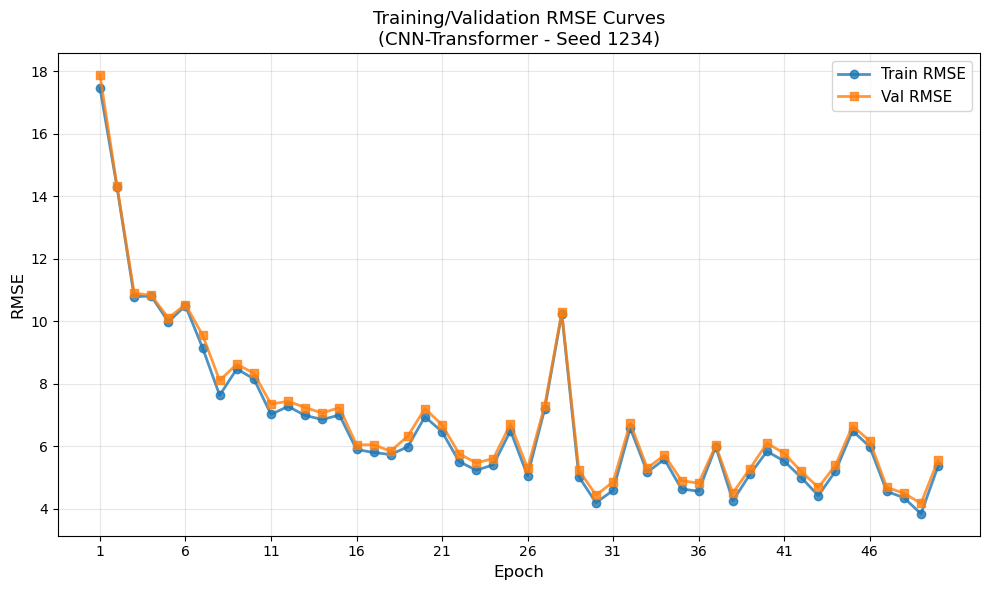

In [48]:
epochs_range = range(1, EPOCHS + 1)
sample_interval = 5

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history["train"], marker='o', linewidth=2, label='Train RMSE', alpha=0.8)
plt.plot(epochs_range, history["val"], marker='s', linewidth=2, label='Val RMSE', alpha=0.8)

# Mark every 5th epoch on x-axis
plt.xticks(range(1, EPOCHS + 1, sample_interval))
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title(f"Training/Validation RMSE Curves\n({BEST_MODEL} - Seed {BEST_SEED})", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Classification Metrics for Best Model
- Convert RUL predictions to binary (threshold = 30).
- Evaluate: accuracy, precision, recall, F1-score, confusion matrix.

In [14]:
# Load test_df for downstream evaluation/use
test_df = pd.read_csv(
    "data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd001_low_variance_1_125.csv"
 )
print("Loaded test_df:", test_df.shape)

Loaded test_df: (13096, 20)


In [49]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# MODEL_PATH = "Hybrid/models/best_hyper_model/GRU_Transformer_FE_Low_Variance_125_seed1234_seq100_d64_lr0.001.pth"
MODEL_PATH = "Hybrid/models/best_hyper_model/GRU_Transformer_FE_Low_Variance_125_seed1234_seq100_d64_lr0.001.pth"
TEST_CSV = "data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd001_low_variance_1_125.csv"
SEQ_LEN = 100
THRESHOLD = 30

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
 )

# Load test data
test_df = pd.read_csv(TEST_CSV)
feature_cols = [col for col in test_df.columns if col.startswith("s") and col[1:].isdigit()]
num_features = len(feature_cols)
print("Loaded test_df:", test_df.shape, "| num_features:", num_features)

# Build model and load weights
model = GRUTransformer(num_features=num_features).to(DEVICE)
state = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

# Prepare one sequence per engine (zero-pad if shorter than SEQ_LEN)
engine_ids = []
x_last = []
for engine_id, group in test_df.groupby("id"):
    seq = group.sort_values("cycle")[feature_cols].values
    if len(seq) < SEQ_LEN:
        pad_len = SEQ_LEN - len(seq)
        pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        seq = np.vstack([pad, seq])
    else:
        seq = seq[-SEQ_LEN:]
    x_last.append(seq)
    engine_ids.append(engine_id)

x_last = np.array(x_last, dtype=np.float32)
x_tensor = torch.tensor(x_last, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    preds = model(x_tensor).cpu().numpy()

results = pd.DataFrame({
    "id": engine_ids,
    "predicted_rul": preds,
})
results["health_state"] = np.where(
    results["predicted_rul"] <= THRESHOLD,
    "Not Healthy",
    "Healthy"
)

print(results["health_state"].value_counts())
results.head()

Loaded test_df: (13096, 20) | num_features: 15
health_state
Healthy        73
Not Healthy    27
Name: count, dtype: int64


,id,predicted_rul,health_state
0,1,124.040154,Healthy
1,2,70.111580,Healthy
2,3,55.278099,Healthy
3,4,74.360085,Healthy
4,5,79.015480,Healthy


Accuracy : 0.9800
Precision: 0.9259
Recall   : 1.0000
F1       : 0.9615


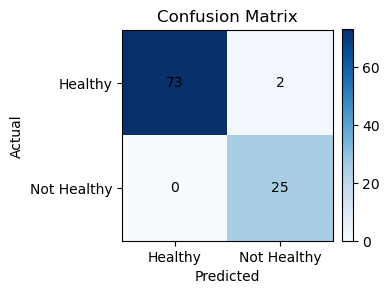

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Ground truth from test_df, aligned to results by engine id
true_rul = test_df.groupby("id")["RUL"].last().reindex(results["id"]).values
y_true = (true_rul <= THRESHOLD).astype(int)
y_pred = (results["predicted_rul"] <= THRESHOLD).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")

labels = ["Healthy", "Not Healthy"]
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Add counts in each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()